### Popularity Model for new generated Bundle based on Weekly Dataset, based on [Popularity Estimation and New Bundle Generation using Content and Context based Embeddings](https://arxiv.org/abs/2412.17310) Paper.

* Same popularity_monthly.ipynb but this time for weekly data

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    mean_absolute_percentage_error
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sentence_transformers import SentenceTransformer
from sklearn.mixture import GaussianMixture
from tqdm import tqdm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE: int = 42 
PercentileCategorization: bool = True

In [2]:
DATASET_FOLDER: str = r"..\..\..\datasets"
WEEKLY_BUNDLES_DATA_PATH: str = rf"{DATASET_FOLDER}\weekly_base_bundles_info_202501_202510.csv"


data = pd.read_csv(WEEKLY_BUNDLES_DATA_PATH) 
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,validity,price,usage_type,configured_volume,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,30 Day(s),4000,CHARGED,1.61,PREPAID,0.0,36000.00,9,10,9
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,30 Day(s),690,CHARGED,2MIN,PREPAID,0.0,3450.00,5,5,5
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,30 Day(s),200,CHARGED,2MIN,PREPAID,0.0,400.00,2,2,1
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,1 Day(s),215,CHARGED,170,PREPAID,0.0,124060.00,577,584,340
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,30 Day(s),50050,CHARGED,Unlimited,PREPAID,0.0,200200.00,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,5 Day(s),335,CHARGED,300sms,PREPAID,0.0,253295.86,772,783,718
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,7 Day(s),525,CHARGED,40 + 3Mins,NaN,0.0,525.00,1,1,1
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,30 Day(s),2999,CHARGED,15MIN,PREPAID,0.0,2999.00,1,1,1
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,7 Day(s),550,CHARGED,500MB,HYBRID,0.0,1650.00,3,3,1


In [3]:
# Extract Configured Volumes 'configured_volume'
def extract_conf_volume_values(volume_str):
    """
    Extract MB, minutes, and SMS from configured_volume string.
    Handles: GB (→ MB), MB, Minutes, SMS, commas, combinations, addition formats, etc.
    """
    if pd.isna(volume_str) or volume_str is None:
        return {'mb': None, 'min': None, 'sms': None}
    
    original_str = str(volume_str)
    if original_str.lower() in ['unlimited', 'illimité', 'illimite']:
        return {'mb': None, 'min': None, 'sms': None}
    
    volume_str = original_str.replace(',', '.')
    volume_str_upper = volume_str.upper()
    
    mb_value = None
    min_value = None
    sms_value = None
    
    # extract GB and convert to MB
    gb_pattern = r'(\d+(?:\.\d+)?)\s*G(?:B)?\b'
    gb_matches = re.findall(gb_pattern, volume_str_upper)
    if gb_matches:
        mb_value = sum(float(gb) for gb in gb_matches) * 1024
    
    # extract MB
    mb_pattern = r'(\d+(?:\.\d+)?)\s*MB\b'
    mb_matches = re.findall(mb_pattern, volume_str_upper)
    if mb_matches:
        total_mb = sum(float(mb) for mb in mb_matches)
        mb_value = total_mb if mb_value is None else mb_value + total_mb
    
    # extract minutes
    min_pattern = r'(\d+(?:\.\d+)?)\s*MINS?\b'
    min_matches = re.findall(min_pattern, volume_str_upper)
    add_pattern_min = r'(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b'
    add_match_min = re.search(add_pattern_min, volume_str_upper)
    
    if add_match_min:
        min_value = float(add_match_min.group(1)) + float(add_match_min.group(2))
    elif min_matches:
        min_value = sum(float(m) for m in min_matches)
    
    # extract SMS
    sms_pattern = r'(\d+(?:\.\d+)?)\s*SMS\b'
    sms_matches = re.findall(sms_pattern, volume_str_upper)
    if sms_matches:
        sms_value = sum(float(sms) for sms in sms_matches)
    
    # handle "/" formats like "200/40 mins"
    slash_pattern = r'(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)'
    slash_match = re.search(slash_pattern, volume_str)
    if slash_match and 'MIN' in volume_str_upper:
        if min_value is None:
            min_value = float(slash_match.group(2))
        if mb_value is None:
            mb_value = float(slash_match.group(1))
    
    # handle seconds
    sec_pattern = r'(\d+(?:\.\d+)?)\s*SEC\b'
    sec_matches = re.findall(sec_pattern, volume_str_upper)
    if sec_matches:
        sec_as_min = sum(float(sec) for sec in sec_matches) / 60.0
        min_value = sec_as_min if min_value is None else min_value + sec_as_min
    
    return {'mb': mb_value, 'min': min_value, 'sms': sms_value}


volume_extracted = data['configured_volume'].apply(extract_conf_volume_values)
data['configured_volume_mb'] = volume_extracted.apply(lambda x: x['mb'] if x['mb'] is not None else 0.0)
data['configured_volume_min'] = volume_extracted.apply(lambda x: x['min'] if x['min'] is not None else 0.0)
data['configured_volume_sms'] = volume_extracted.apply(lambda x: x['sms'] if x['sms'] is not None else 0.0)
data.drop(columns=['configured_volume'], inplace=True)

In [4]:
def clean_price(val) -> float:
        if pd.isna(val):
            return None
        val = str(val).replace("F", "").replace(",", "")
        try:
            return float(val)
        except:
            return None
        
data["price"] = data["price"].apply(clean_price)

In [5]:
data['clean_validity'] = np.where(
    data['validity'].str.strip().str.lower().isin(['null', '']) | data['validity'].isna(),
    None,
    data['validity']
        .str.strip()
        .str.lower()
        .str.replace(r'\(s\)', '', regex=True)         # remove (s)
        .str.replace(r'\bday\b', 'days', regex=True)  # day → days
        .str.replace(r'\bmonth\b', 'months', regex=True)  # month → months
)
data.drop(columns=['validity'], inplace=True)
data = data.rename(columns={"clean_validity": "validity"})


In [6]:
def parse_validity_to_hours(val):
    """
    Convert variants like '7 days', '4 hours', '3 months', '1  days', None -> hours (float)
    Uses 30 days per month convention for telecom.
    Returns np.nan if cannot parse.
    """
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)):
        # unexpected numeric — treat as days
        return float(val) * 24.0
    s = str(val).strip().lower()
    # correct double spaces
    s = re.sub(r"\s+", " ", s)
    # find number
    m = re.match(r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?", s)
    if not m:
        return np.nan
    num = float(m.group(1))
    unit = m.group(3) or "days"
    if "hour" in unit:
        return num
    if "day" in unit:
        return num * 24.0
    if "month" in unit:
        return num * 30.0 * 24.0
    # fallback assume days
    return num * 24.0

data['validity_hours'] = data['validity'].apply(parse_validity_to_hours)

In [7]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_duration,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,0.0,36000.00,9,10,9,0.0,0.0,0.0,30 days,720.0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,0.0,3450.00,5,5,5,0.0,2.0,0.0,30 days,720.0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,0.0,400.00,2,2,1,0.0,2.0,0.0,30 days,720.0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,0.0,124060.00,577,584,340,0.0,0.0,0.0,1 days,24.0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,0.0,200200.00,4,4,4,0.0,0.0,0.0,30 days,720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,0.0,253295.86,772,783,718,0.0,0.0,300.0,5 days,120.0
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,NaN,0.0,525.00,1,1,1,0.0,43.0,0.0,7 days,168.0
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,0.0,2999.00,1,1,1,0.0,15.0,0.0,30 days,720.0
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,0.0,1650.00,3,3,1,500.0,0.0,0.0,7 days,168.0


In [8]:
# For Now we will remove the outliers bundles like DIY
print(data[data['bundle_name'].str.contains("DIY", case=False, na=False)]['bundle_name'].unique())
data[(data['price'].isna()) & ~(data['bundle_name'].str.contains("DIY", case=False, na=False))]['bundle_name'].unique()

['Forfait DIY COMBO DATA LOW' 'Forfait DIY VOICE ONNET'
 'Forfait DIY DATA MEDIUM' 'Forfait DIY DATA NO CHOICE'
 'Forfait DIY DATA HIGH' 'Forfait DIY DATA LOW'
 'Forfait DIY COMBO DATA HIGH' 'Forfait DIY COMBO DATA VERY HIGH'
 'Forfait DIY COMBO DATA MEDIUM' 'BONUS 1GB DIY COMBO on 1st Subscription']


array(['MTN ME2U', 'MTN Call Me Back', 'FORFAIT PRO STAFF CHANGE OFFER',
       'SMS Bundle @F ', nan, 'SDP VAS', 'MTN Xtratime',
       'Forfait LTE Vitesse 2 Mbps 6 mois@785700F',
       'Forfait LTE Vitesse 2 Mbps 12 mois@1539000F',
       'Forfait LTE Vitesse 1 Mbps 6 mois@465600F',
       'Forfait LTE Vitesse 1 Mbps 12 mois@912000F', 'MTN Tv',
       'Forfait LTE Vitesse 4 Mbps 6 mois@1222200F',
       'Bonus 5 mins forfait pro',
       'WIFIX BIZ Premium Offnet Voice 30 Jours', 'Pack Premium Internet',
       'Forfait LTE Vitesse 4 Mbps 3 mois@617400F',
       'Forfait LTE Vitesse 1 Mbps 3 mois@235200F',
       'Forfait Mifi 30 Jours 100GB@50000F',
       'Forfait weekend CVM 2GB 1 Jour@650F'], dtype=object)

In [9]:
data = data[~data["bundle_name"].str.contains("DIY", case=False, na=False)]

In [10]:
data.drop(columns=['total_duration'], inplace=True)
data.dropna(subset=['bundle_name'], inplace=True)

In [11]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,10,9,0.0,0.0,0.0,30 days,720.0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,5,5,0.0,2.0,0.0,30 days,720.0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,2,1,0.0,2.0,0.0,30 days,720.0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,584,340,0.0,0.0,0.0,1 days,24.0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,4,4,0.0,0.0,0.0,30 days,720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,253295.86,772,783,718,0.0,0.0,300.0,5 days,120.0
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,NaN,525.00,1,1,1,0.0,43.0,0.0,7 days,168.0
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,2999.00,1,1,1,0.0,15.0,0.0,30 days,720.0
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,1650.00,3,3,1,500.0,0.0,0.0,7 days,168.0


In [12]:
data['service_class_category'].value_counts()

service_class_category
PREPAID     28250
HYBRID       9631
STAFF        2968
POSTPAID      112
Name: count, dtype: int64

In [13]:
data['service_class_category'] = data['service_class_category'].fillna(data['service_class_category'].mode()[0])

In [14]:
data['validity'] = data['validity'].fillna('NO_VALIDITY')
data['validity_hours'] = data['validity_hours'].fillna(0)

In [15]:
data[data['price'].isna()]['bundle_name'].value_counts()

bundle_name
SDP VAS                                        190
MTN ME2U                                       164
MTN Call Me Back                               100
SMS Bundle @F                                   44
MTN Tv                                          41
MTN Xtratime                                    21
FORFAIT PRO STAFF CHANGE OFFER                  12
Forfait Mifi 30 Jours 100GB@50000F               7
Forfait LTE Vitesse 2 Mbps 6 mois@785700F        5
Pack Premium Internet                            2
Forfait weekend CVM 2GB 1 Jour@650F              2
Forfait LTE Vitesse 1 Mbps 12 mois@912000F       1
Forfait LTE Vitesse 1 Mbps 6 mois@465600F        1
Forfait LTE Vitesse 2 Mbps 12 mois@1539000F      1
Forfait LTE Vitesse 4 Mbps 6 mois@1222200F       1
WIFIX BIZ Premium Offnet Voice 30 Jours          1
Bonus 5 mins forfait pro                         1
Forfait LTE Vitesse 1 Mbps 3 mois@235200F        1
Forfait LTE Vitesse 4 Mbps 3 mois@617400F        1
Name: count, dtype:

In [16]:
def extract_price(text):
    if pd.isna(text):
        return None
    match = re.search(r'@(\d+)\s*F', str(text))
    if match:
        return float(match.group(1))
    return None

# try to extract price from bundle_name for all rows with missing price
mask_missing_price = data['price'].isna()
data.loc[mask_missing_price, 'price_extracted'] = \
    data.loc[mask_missing_price, 'bundle_name'].apply(extract_price)

# fill price where extraction was successful
data['price'] = data['price'].fillna(data['price_extracted'])


# 4. FREE bundles (@F)
free_mask = data['bundle_name'].str.contains('@F', na=False)
data.loc[free_mask, 'price'] = 0

# STAFF bundles
staff_mask = data['bundle_name'].str.contains('STAFF', na=False, case=False)
data.loc[staff_mask, 'price'] = 0

# VAS services and system events
system_names = ['SDP VAS', 'MTN ME2U', 'MTN Xtratime', 
                'MTN Call Me Back', 'MTN Tv']

system_mask = data['bundle_name'].isin(system_names)
data.loc[system_mask, 'price'] = 0

# Anything still missing → truly unknown, set to zero but mark category
still_missing = data['price'].isna()
data.loc[still_missing, 'price'] = 0

data.drop(columns=['price_extracted'], inplace=True)

In [17]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,10,9,0.0,0.0,0.0,30 days,720.0
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,5,5,0.0,2.0,0.0,30 days,720.0
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,2,1,0.0,2.0,0.0,30 days,720.0
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,584,340,0.0,0.0,0.0,1 days,24.0
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,4,4,0.0,0.0,0.0,30 days,720.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,253295.86,772,783,718,0.0,0.0,300.0,5 days,120.0
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,525.00,1,1,1,0.0,43.0,0.0,7 days,168.0
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,2999.00,1,1,1,0.0,15.0,0.0,30 days,720.0
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,1650.00,3,3,1,500.0,0.0,0.0,7 days,168.0


## Define Telecom Popularity Bundle function

In [18]:
def norm(col, eps=1e-9):
    col = np.log1p(col)  # compress heavy tails
    return (col - col.min()) / (col.max() - col.min() + eps)


def compute_popularity(df, n_components=128, n_clusters=20, eps=1e-9):
    """
    Compute popularity using TF-IDF embeddings 
    """
    df = df.copy()

    df["P_e_norm"] = norm(df["total_subscriptions"])
    df["R_norm"]   = norm(df["total_rev"])
    df["U_norm"]   = norm(df["unique_users"])
    df["A_norm"]   = norm(df["total_sessions"])

    df["N0_norm"]  = df["total_sessions"].apply(lambda x: 1 if x==0 else 0)

    # TF-IDF vectorization
    print("TF-IDF vectorization")
    vectorizer = TfidfVectorizer(
        analyzer="word",
        stop_words="english",
        max_features=5000
    )
    X_tfidf = vectorizer.fit_transform(df["bundle_name"])

    # Dimensionality reduction (SVD acts like LSA embeddings)
    print("Dimensionality reduction")
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_emb = svd.fit_transform(X_tfidf)

    df["embedding"] = list(X_emb)

    print(f"{len(X_emb)} Embdedd.")
    # compute diversity
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_emb)
    centroids = kmeans.cluster_centers_

    def diversity(idx, emb):
        centroid = centroids[labels[idx]]
        cos = np.dot(emb, centroid) / (np.linalg.norm(emb) * np.linalg.norm(centroid) + eps)
        return 1 - cos

    df["D"] = [diversity(i, emb) for i, emb in enumerate(X_emb)]
    df["D_norm"] = norm(df["D"])

    # populatiry func
    α, β, γ, η, ζ = 0.35, 0.30, 0.20, 0.10, 0.0500000000000001
    
    df["popularity_score"] = (
        α * df["P_e_norm"] +
        β * df["R_norm"] +
        γ * df["U_norm"] +
        η * (1 - df["N0_norm"]) + 
        ζ * df["D_norm"]
    )
    print("populatiry func computed")
    df["cluster"] = labels
    return df, X_emb, kmeans

data_pop, embeddings, kmeans_model = compute_popularity(data)

TF-IDF vectorization
Dimensionality reduction
41486 Embdedd.
populatiry func computed


In [19]:
data_pop['popularity_score'].fillna(data_pop['popularity_score'].median(), inplace=True)

In [20]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(embeddings, data_pop["cluster"])
sil_score

0.10922799854981201

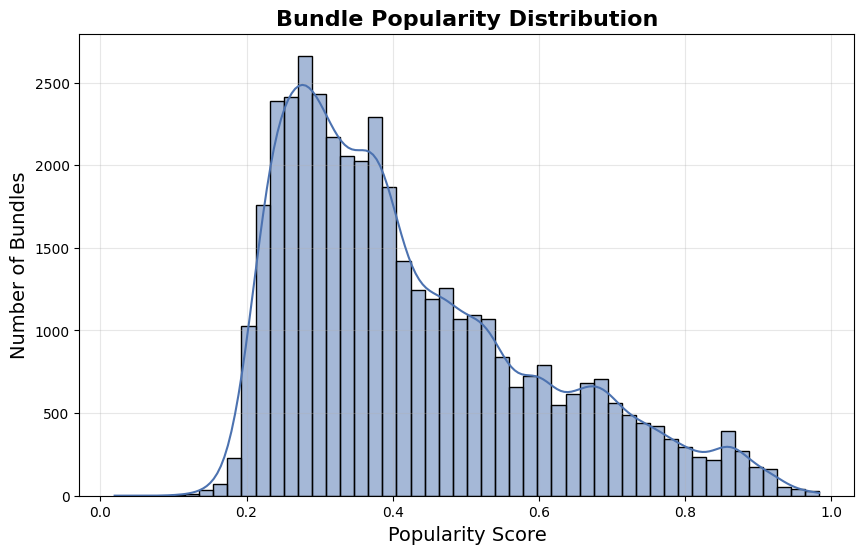

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(data_pop['popularity_score'], bins=50, kde=True, color="#4C72B0", edgecolor='black')
plt.title("Bundle Popularity Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Popularity Score", fontsize=14)
plt.ylabel("Number of Bundles", fontsize=14)
plt.grid(alpha=0.3)
plt.show()


In [21]:
data.loc[:, 'popularity'] = data_pop['popularity_score'].values

In [22]:
if PercentileCategorization:
    p40 = data['popularity'].quantile(0.40)
    p80 = data['popularity'].quantile(0.80)
    data['popularity_category'] = pd.cut(
        data['popularity'],
        bins=[-float('inf'), p40, p80, float('inf')],
        labels=["Unpopular", "Popular", "Very Popular"],
        include_lowest=True
    )

    def popularity_category(score):
        if score >= p80:
            return "Very Popular"     # top 20%
        elif score >= p40:
            return "Popular"          # middle 40%
        else:
            return "Unpopular"        # bottom 40%

    data['popularity_category'] = data['popularity'].apply(popularity_category)
    print(data['popularity_category'].value_counts())

popularity_category
Popular         16595
Unpopular       16593
Very Popular     8298
Name: count, dtype: int64


In [23]:
# Detemine the best thresholds based on Gaussian Mixture
if not PercentileCategorization:
    scores = data_pop["popularity_score"].values.reshape(-1, 1)

    # Fit GMM
    gmm = GaussianMixture(n_components=3, random_state=42).fit(scores)
    labels = gmm.predict(scores)
    probs = gmm.predict_proba(scores)
    means = gmm.means_.flatten()
    std_devs = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_.flatten()

    # Sort components by mean
    order = np.argsort(means)
    means = means[order]
    std_devs = std_devs[order]
    weights = weights[order]

    thresholds = np.sort(gmm.means_.flatten())
    print("derived thresholds:", thresholds)

    # Plot 1: Distribution with individual components
    x_axis = np.linspace(scores.min(), scores.max(), 500).reshape(-1, 1)
    logprob = gmm.score_samples(x_axis)
    pdf = np.exp(logprob)

    colors = ['red', 'green', 'blue']
    component_names = ['Low Popularity', 'Medium Popularity', 'High Popularity']

    thresholds = []
    for i in range(len(means)-1):
        threshold = (means[i] + means[i+1]) / 2
        thresholds.append(threshold)

    # Create comprehensive figure
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Enhanced distribution with decision boundaries
    ax1.hist(scores, bins=50, alpha=0.3, density=True, color='lightblue', edgecolor='black')
    ax1.plot(x_axis, pdf, 'k-', linewidth=2, label='GMM Fit')

    # Add decision boundaries
    for i, threshold in enumerate(thresholds):
        ax1.axvline(threshold, color='red', linestyle='--', linewidth=2, 
                    label=f'Boundary {i+1}: {threshold:.2f}')

    ax1.set_title('Distribution with Decision Boundaries', fontweight='bold')
    ax1.set_xlabel('Popularity Score')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Component probabilities
    for i, (color, name) in enumerate(zip(colors, component_names)):
        ax2.hist(probs[:, order[i]], bins=30, alpha=0.6, color=color, label=name)
    ax2.set_title('Assignment Probabilities by Component', fontweight='bold')
    ax2.set_xlabel('Probability')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Summary statistics
    categories = component_names
    counts = [np.sum(labels == order[i]) for i in range(3)]
    percentages = [count/len(scores)*100 for count in counts]

    bars = ax3.bar(categories, counts, color=colors, alpha=0.7)
    ax3.set_title('Item Count by Popularity Category', fontweight='bold')
    ax3.set_ylabel('Number of Items')

    # Add percentage labels on bars
    for bar, percentage in zip(bars, percentages):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{percentage:.1f}%', ha='center', va='bottom')

    # Plot 4: Statistical summary
    stats_data = {
        'Mean': means,
        'Std Dev': std_devs,
        'Weight': weights
    }

    ax4.axis('off')
    table_data = [[f'{val:.3f}' for val in stats_data[key]] for key in stats_data]
    table = ax4.table(cellText=table_data,
                    rowLabels=list(stats_data.keys()),
                    colLabels=component_names,
                    cellLoc='center',
                    loc='center',
                    bbox=[0.1, 0.3, 0.8, 0.4])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    ax4.set_title('GMM Component Statistics', fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
if  not PercentileCategorization:
    threshold_low = (means[0] + means[1]) / 2   # midpoint between first and second mean
    threshold_high = (means[1] + means[2]) / 2  # midpoint between second and third mean

    print("Thresholds for categories:", threshold_low, threshold_high)

    def gmm_category(score):
        if score < threshold_low:
            return "unpopular"
        elif score < threshold_high:
            return "popular"
        else:
            return "very popular"
        
    data["popularity_category"] = data["popularity"].apply(gmm_category)
    print(data["popularity_category"].value_counts())

In [25]:
data.sort_values(by='popularity', ascending=False)

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,popularity,popularity_category
37749,40,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.904338e+08,952171,952171,388275,0.0,16.0,0.0,1 days,24.0,0.983588,Very Popular
39153,41,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.899620e+08,949812,949812,386721,0.0,16.0,0.0,1 days,24.0,0.983417,Very Popular
33852,36,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.908463e+08,954233,954233,379021,0.0,16.0,0.0,1 days,24.0,0.983284,Very Popular
34849,37,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.877384e+08,938692,938692,377995,0.0,16.0,0.0,1 days,24.0,0.982542,Very Popular
35667,38,2025,FVX1D200FV3,Forfait Maxivoice 16Mins 1 jour@200F,BUNDLE_VOICE,200.0,CHARGED,PREPAID,1.850800e+08,925401,925401,377597,0.0,16.0,0.0,1 days,24.0,0.981918,Very Popular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9320,11,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,STAFF,1.000000e-01,1,1,1,0.0,0.0,300.0,5 days,120.0,0.115118,Unpopular
14419,16,2025,9031,100 SMS vers MTN ou 30 vers autre 3 jours@122F,BUNDLE_SMS,122.0,CHARGED,STAFF,1.100000e-01,1,1,1,0.0,0.0,100.0,3 days,72.0,0.114499,Unpopular
38840,41,2025,CLOUDPBX224MN5742F,Voice Bundle 31 Days @5742F 224min,BUNDLE_VOICE,5742.0,CHARGED,PREPAID,0.000000e+00,2,2,1,0.0,224.0,0.0,31 days,744.0,0.113796,Unpopular
12605,14,2025,SYSMODE,MTN Xtratime,VAS,0.0,CHARGED,PREPAID,1.275000e+02,2,0,1,0.0,0.0,0.0,NO_VALIDITY,0.0,0.105363,Unpopular


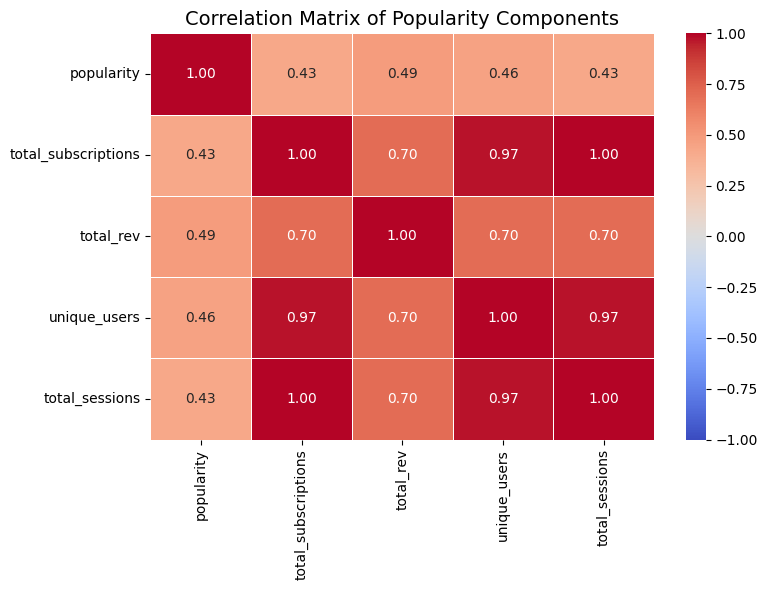

In [26]:
corr = data[['popularity','total_subscriptions','total_rev','unique_users','total_sessions']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,        
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Popularity Components", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
import plotly.express as px

fig = px.scatter_3d(
    data,
    x='total_subscriptions',
    y='total_rev',
    z='popularity',
    color='unique_users',
    size='unique_users',
    hover_name='bundle_name'
)

fig.show()

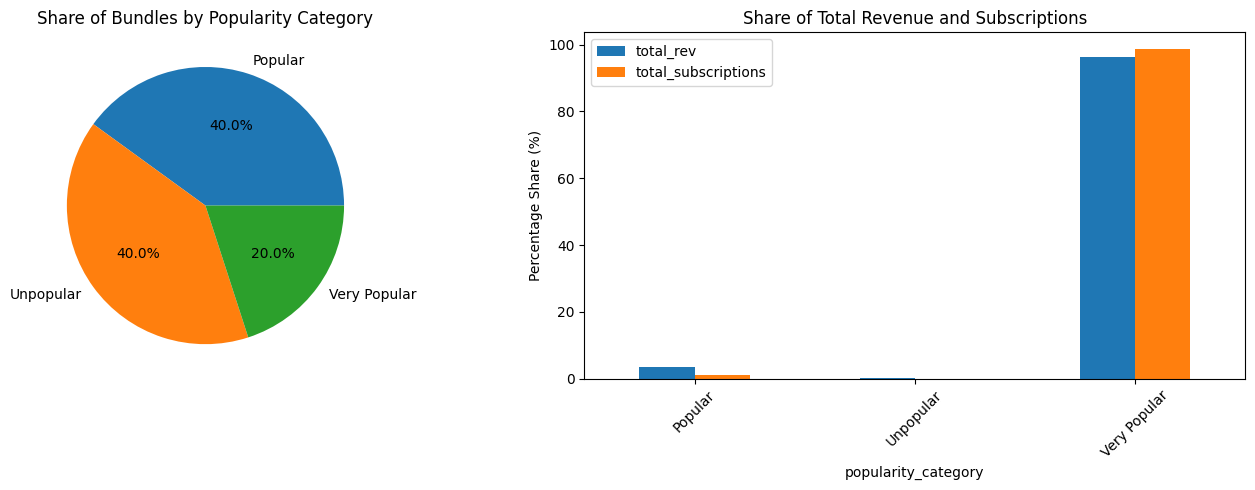

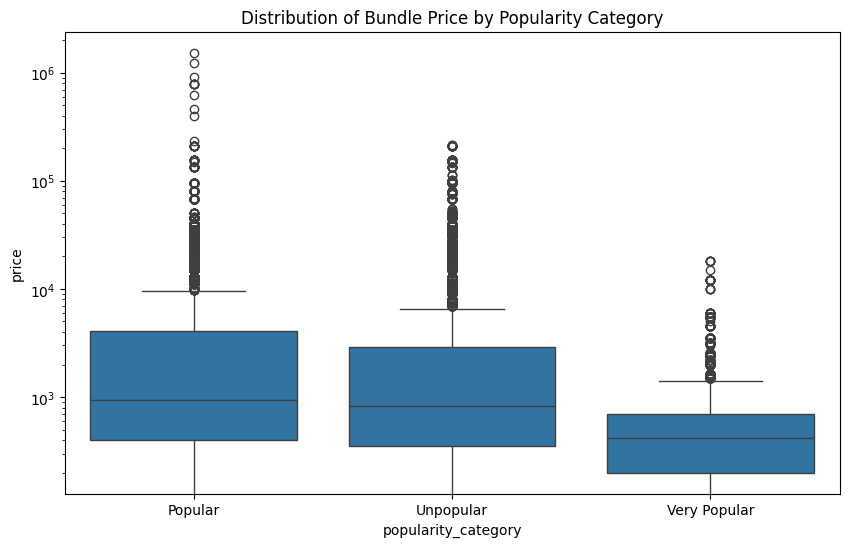

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

data['popularity_category'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax1, title='Share of Bundles by Popularity Category')
ax1.set_ylabel('')

summary_df = data.groupby('popularity_category').agg({
    'total_rev': 'sum',
    'total_subscriptions': 'sum'
}).apply(lambda x: 100 * x / x.sum()) 

summary_df.plot.bar(ax=ax2, title='Share of Total Revenue and Subscriptions')
ax2.set_ylabel('Percentage Share (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='popularity_category', y='price')
plt.yscale('log') 
plt.title('Distribution of Bundle Price by Popularity Category')
plt.show()

In [29]:
data

,week_number,year_number,bundle_id,bundle_name,bundle_type,price,usage_type,service_class_category,total_rev,total_subscriptions,total_sessions,unique_users,configured_volume_mb,configured_volume_min,configured_volume_sms,validity,validity_hours,popularity,popularity_category
0,1,2025,37076,Forfait 1.6Go 30 jours@4000F,BUNDLE_DATA,4000.0,CHARGED,PREPAID,36000.00,9,10,9,0.0,0.0,0.0,30 days,720.0,0.360925,Popular
1,1,2025,50134,Forfait appels RCA 2 mins 30 jours@690F,INT_BUNDLE_VOICE,690.0,CHARGED,PREPAID,3450.00,5,5,5,0.0,2.0,0.0,30 days,720.0,0.287411,Unpopular
2,1,2025,50129,Forfait appels Nigeria 2 mins 30 jours@200F,INT_BUNDLE_VOICE,200.0,CHARGED,PREPAID,400.00,2,2,1,0.0,2.0,0.0,30 days,720.0,0.221367,Unpopular
3,1,2025,35070,Forfait 1 jour 170MB@215F,BUNDLE_DATA,215.0,CHARGED,PREPAID,124060.00,577,584,340,0.0,0.0,0.0,1 days,24.0,0.557487,Popular
4,1,2025,36667,NDAKO BOX ILLIMITE@50050F,BUNDLE_DATA,50050.0,CHARGED,PREPAID,200200.00,4,4,4,0.0,0.0,0.0,30 days,720.0,0.348931,Popular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42372,44,2025,9032,300 SMS vers MTN ou 83 vers autre 5 jours@335F,BUNDLE_SMS,335.0,CHARGED,PREPAID,253295.86,772,783,718,0.0,0.0,300.0,5 days,120.0,0.565502,Popular
42373,44,2025,FVX7D525FV4,MaGicvoice 40+3Mins 7 jours@525F,BUNDLE_VOICE,525.0,CHARGED,PREPAID,525.00,1,1,1,0.0,43.0,0.0,7 days,168.0,0.243593,Unpopular
42374,44,2025,50155,Forfait appels Cote d Ivoire 15 mins 30 jours@...,INT_BUNDLE_VOICE,2999.0,CHARGED,PREPAID,2999.00,1,1,1,0.0,15.0,0.0,30 days,720.0,0.249665,Unpopular
42375,44,2025,36203,Maxinet Debutant 500MB 7 jours@550F,BUNDLE_DATA,550.0,CHARGED,HYBRID,1650.00,3,3,1,500.0,0.0,0.0,7 days,168.0,0.277259,Unpopular


## Popularity Regression Model 

In [189]:
X = data[
    [
        "week_number", "bundle_name", "bundle_type",  "price",
        "usage_type", "service_class_category", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
].copy()
 
y = data["popularity"].astype(float)

assert len(X) == len(y)

In [190]:
groups = X["bundle_name"]

# Create the group-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.05, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

# Optional: check
print("Training bundles:", X_train["bundle_name"].nunique())
print("Testing bundles:", X_test["bundle_name"].nunique())
print("Overlap:", len(set(X_train["bundle_name"]) & set(X_test["bundle_name"])))

Training bundles: 989
Testing bundles: 53
Overlap: 0


In [ ]:
def feature_engineering_fit(df, y):
    df = df.copy()
    # SAFETY: drop target if present
    if "popularity" in df.columns:
        df = df.drop(columns=["popularity"])
        
    cat_cols = ["bundle_type", "usage_type", "service_class_category"]

    # week features
    df['week_sin'] = np.sin(2 * np.pi * df['week_number'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_number'] / 52)

    # target encoding: FIT ON TRAIN ONLY
    te = TargetEncoder()
    df[cat_cols] = te.fit_transform(df[cat_cols], y)

    # text embedding: fit PCA on TRAIN only
    st_model = SentenceTransformer("all-MiniLM-L6-v2")
    name_emb = st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
    pca = PCA(n_components=32, random_state=42)
    name_emb_pca = pca.fit_transform(name_emb)

    for i in range(name_emb_pca.shape[1]):
        df[f"name_emb_{i}"] = name_emb_pca[:, i]

    # select numeric features
    numeric_df = df.select_dtypes(include=[float, int]).copy()
    scaler = StandardScaler()
    X = scaler.fit_transform(numeric_df)

    X = pd.DataFrame(X, columns=numeric_df.columns)

    return X, te, st_model, pca, scaler, numeric_df.columns.tolist()


def feature_engineering_apply(df, te, st_model, pca, scaler, numeric_cols):
    df = df.copy()
    cat_cols = ["bundle_type", "usage_type", "service_class_category"]

    df['week_sin'] = np.sin(2 * np.pi * df['week_number'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_number'] / 52)

    # use te.transform (NO y)
    df[cat_cols] = te.transform(df[cat_cols])

    name_emb = st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
    name_emb_pca = pca.transform(name_emb)
    for i in range(name_emb_pca.shape[1]):
        df[f"name_emb_{i}"] = name_emb_pca[:, i]

    numeric_df = df[numeric_cols].copy()
    X = scaler.transform(numeric_df)
    X = pd.DataFrame(X, columns=numeric_cols)

    return X

#def add_value_features(df):
#    df = df.copy()
#    eps = 1e-6

#    df["price_per_mb"]  = df["price"] / (df["configured_volume_mb"]  + eps)
#    df["price_per_min"] = df["price"] / (df["configured_volume_min"] + eps)
#    df["price_per_sms"] = df["price"] / (df["configured_volume_sms"] + eps)

    # Handle infs/NaNs
#    for col in ["price_per_mb", "price_per_min", "price_per_sms"]:
#        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
#        df[col] = df[col].fillna(df[col].max())

    # Optional log versions
#    for col in ["price", "configured_volume_mb", "configured_volume_min",
#                "configured_volume_sms", "validity_hours"]:
#        df[f"log_{col}"] = np.log1p(df[col])

#    return df


#X_train_ext = add_value_features(X_train)
#X_test_ext  = add_value_features(X_test)

X_train_fe, te, st_model, pca, scaler, numeric_cols = feature_engineering_fit(
    X_train, y_train
)
X_test_fe = feature_engineering_apply(
    X_test, te, st_model, pca, scaler, numeric_cols
)


In [192]:
X_train_fe

,week_number,bundle_type,price,usage_type,service_class_category,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,price_per_mb,...,name_emb_22,name_emb_23,name_emb_24,name_emb_25,name_emb_26,name_emb_27,name_emb_28,name_emb_29,name_emb_30,name_emb_31
0,-1.743880,0.188984,-0.030969,-0.141961,0.643211,-0.167113,-0.287916,-0.090560,1.506982,0.123194,...,0.654801,0.834333,0.852109,0.977173,0.100624,0.246908,0.248530,-1.619964,-0.505946,-0.595899
1,-1.743880,-2.317770,-0.201497,-0.047906,0.648299,-0.167113,-0.268941,-0.090560,1.506982,-0.062910,...,-0.995162,0.562001,-1.661195,1.447599,-0.930348,1.281799,1.973730,2.295586,1.189846,-1.850026
2,-1.743880,-2.354069,-0.226742,0.103558,0.640152,-0.167113,-0.268941,-0.090560,1.506982,-0.090460,...,1.229809,1.594572,2.326175,0.799567,0.409992,0.221901,0.278263,0.557980,-0.417601,-2.003523
3,-1.743880,0.225090,-0.225969,0.011452,0.640815,-0.167113,-0.287916,-0.090560,-0.764099,-0.089617,...,-1.060892,1.323783,0.126261,-0.302940,0.345039,0.211511,-1.779974,-0.781894,0.394442,-1.253205
4,-1.743880,0.217475,2.341492,-0.047906,0.648299,-0.167113,-0.287916,-0.090560,1.506982,2.712352,...,-0.534264,3.406647,-1.018677,0.944908,1.282939,-1.044971,1.217458,1.531743,-1.489791,1.240592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39234,1.678186,0.801326,-0.219787,0.103558,0.640152,-0.167113,-0.287916,9.414159,-0.450846,-0.082870,...,1.593395,-1.062536,0.045062,-0.969128,-1.179513,0.252098,0.735551,-0.758200,0.706471,2.575979
39235,1.678186,0.474308,-0.209998,0.011452,0.640815,-0.167113,0.120048,-0.090560,-0.294220,-0.072187,...,0.258910,0.113369,1.505942,1.283965,-0.163632,0.582328,-0.752735,-1.406855,-0.008355,1.606904
39236,1.678186,-2.317770,-0.082539,-0.047906,0.648299,-0.167113,-0.145603,-0.090560,1.506982,0.066913,...,0.171770,-0.654118,-0.839869,0.139961,-0.873061,-1.367393,-1.096529,-1.222744,-0.208629,2.035111
39237,1.678186,0.222180,-0.208710,0.148488,-1.251251,-0.162013,-0.287916,-0.090560,-0.294220,-0.101705,...,1.045927,0.125744,-2.103567,0.580252,1.242685,1.395534,0.573465,2.465814,-0.145563,-0.196559


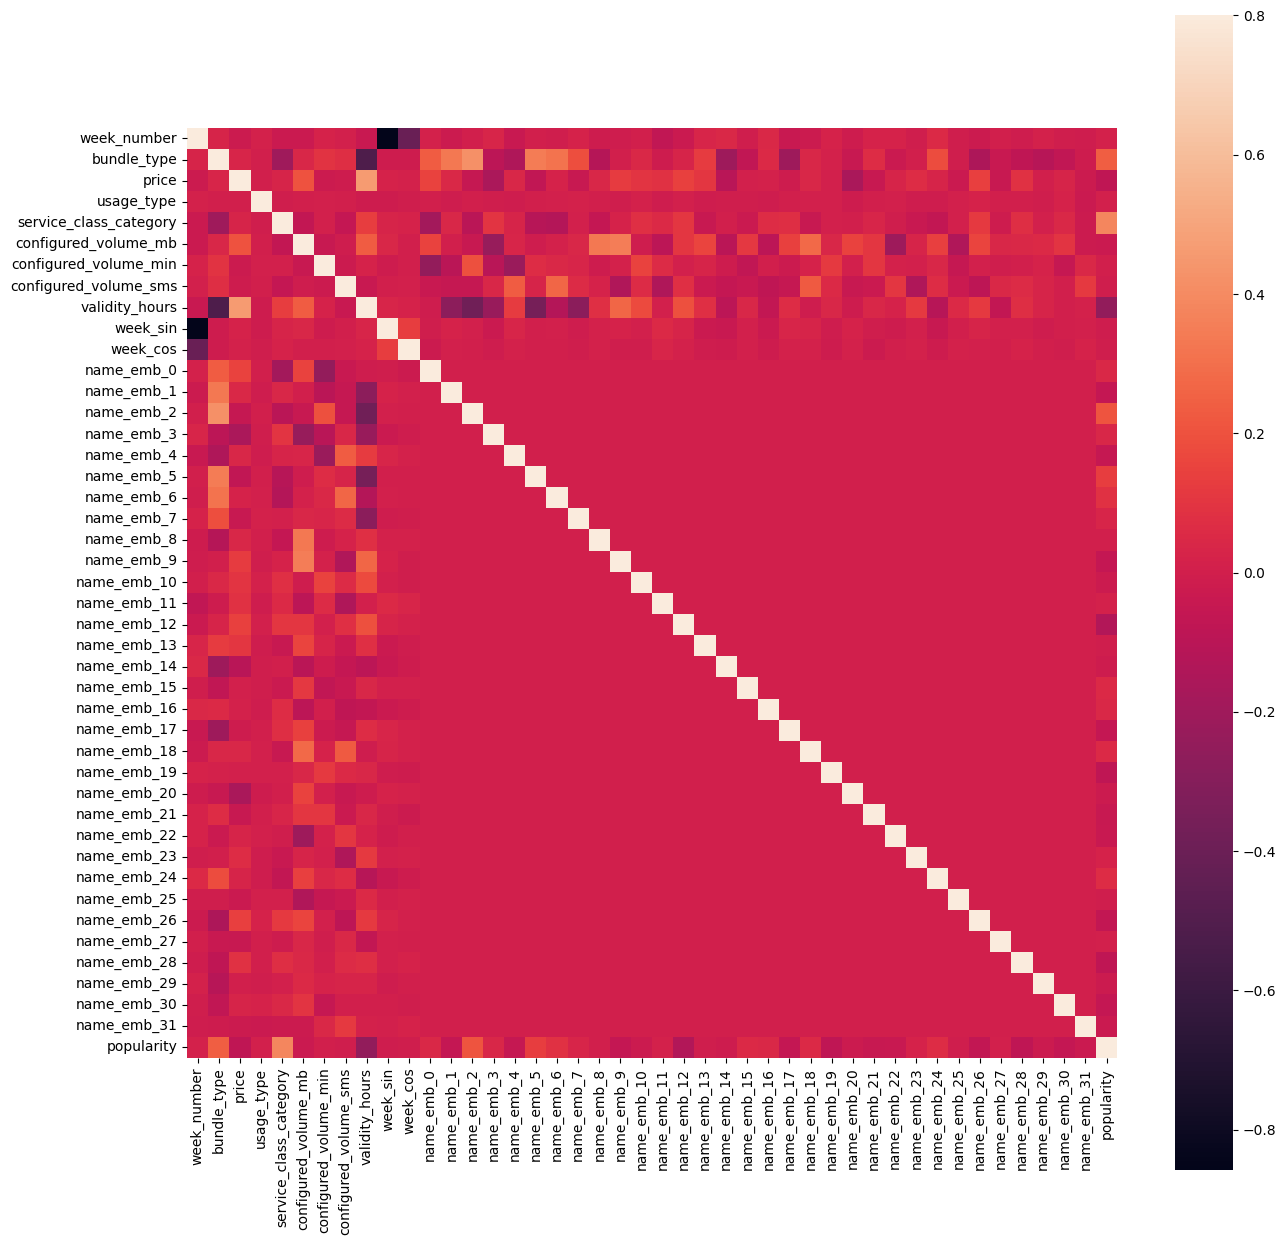

In [ ]:
train_data = X_train_fe.copy()
train_data['popularity'] = y_train

C_mat = train_data.corr()
fig = plt.figure(figsize = (15,15))

sns.heatmap(C_mat, vmax = .8, square = True)
plt.show()
del train_data

In [193]:
X_train_ready = X_train_fe.values
X_test_ready = X_test_fe.values

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=250, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
    ),
    "AdaBoost": AdaBoostRegressor(n_estimators=200, random_state=42),
    "SVR (RBF Kernel)": SVR(C=2.0, epsilon=0.1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=7),
    "LGBMRegressor": lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.01,
        max_depth=-1,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
    ),
}

results = []
for name, model in tqdm(models.items(), total=len(models)):
    model.fit(X_train_ready, y_train)
    y_pred = model.predict(X_test_ready)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)

    results.append([name, rmse, mae, mape, r2, evs])

results_df = pd.DataFrame(
    results, columns=["Model", "RMSE", "MAE", "MAPE", "R2", "Explained Variance"]
).sort_values("RMSE")
results_df

 80%|████████  | 8/10 [02:27<00:41, 20.57s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10322
[LightGBM] [Info] Number of data points in the train set: 39239, number of used features: 51
[LightGBM] [Info] Start training from score 0.424516


100%|██████████| 10/10 [02:29<00:00, 14.93s/it]


,Model,RMSE,MAE,MAPE,R2,Explained Variance
9,LGBMRegressor,0.121461,0.088214,0.217572,0.584958,0.595134
5,Gradient Boosting,0.125445,0.093073,0.233929,0.557286,0.577060
7,SVR (RBF Kernel),0.128076,0.093073,0.243728,0.538519,0.547825
4,Random Forest,0.136730,0.096023,0.234375,0.474051,0.487106
6,AdaBoost,0.137763,0.102116,0.255341,0.466072,0.473043
2,Lasso Regression,0.140928,0.107952,0.268781,0.441258,0.447648
1,Ridge Regression,0.141898,0.108286,0.269599,0.433534,0.439383
0,Linear Regression,0.141901,0.108298,0.269621,0.433515,0.439376
8,KNN Regressor,0.146012,0.104164,0.264771,0.400214,0.400322
3,Decision Tree,0.157768,0.117892,0.284594,0.299745,0.317893


In [181]:
from sklearn.model_selection import GroupKFold, cross_val_score

groups_train = X_train["bundle_name"] 

lgbm_base = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
)

gkf = GroupKFold(n_splits=5)

cv_scores = cross_val_score(
    lgbm_base,
    X_train_fe,
    y_train,
    cv=gkf.split(X_train_fe, y_train, groups_train),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

print("CV RMSE mean:", -cv_scores.mean(), "std:", cv_scores.std())

CV RMSE mean: 0.1246582869037283 std: 0.003341039217858963


In [182]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "num_leaves": [31, 63, 127, 255],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "n_estimators": [500, 800, 1200, 1500],
    "min_child_samples": [10, 20, 40, 80],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.3, 0.5],
    "reg_lambda": [0.0, 0.1, 0.3, 0.5],
}

lgbm = lgb.LGBMRegressor(random_state=42)
gkf = GroupKFold(n_splits=5)

search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=gkf.split(X_train_fe, y_train, groups_train),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train_fe, y_train)
print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)

best_lgbm = search.best_estimator_
y_pred_test = best_lgbm.predict(X_test_fe)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003636 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8945
[LightGBM] [Info] Number of data points in the train set: 39239, number of used features: 43
[LightGBM] [Info] Start training from score 0.424516
Best params: {'subsample': 0.8, 'reg_lambda': 0.3, 'reg_alpha': 0.5, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 80, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV RMSE: 0.12196895653795425
Test RMSE: 0.11849615723264191


In [194]:
my_lgbm = lgb.LGBMRegressor(
        n_estimators=800,
        learning_rate=0.01,
        max_depth=-1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=0.3,
        random_state=42,
        min_child_samples=80       
)
my_lgbm.fit(X_train_ready, y_train)
y_pred = my_lgbm.predict(X_test_ready)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
print(f"rmse: {rmse}, mae: {mae}, mape: {mape}, r2: {r2}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10322
[LightGBM] [Info] Number of data points in the train set: 39239, number of used features: 51
[LightGBM] [Info] Start training from score 0.424516
rmse: 0.11890378341379598, mae: 0.08607447797768462, mape: 0.2147438192560185, r2: 0.6022499814464184


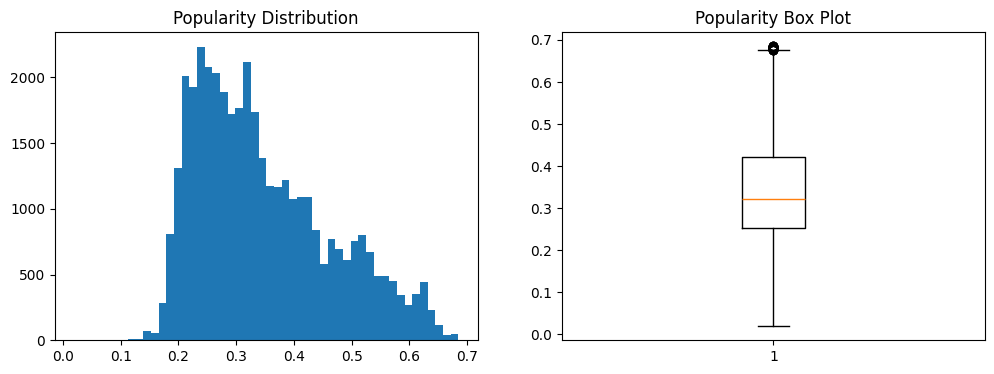

Skewness: 0.696
Kurtosis: -0.373


In [143]:
# First, analyze your target distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(np.log1p(y_train), bins=50)
plt.title('Popularity Distribution')

plt.subplot(1, 2, 2)
plt.boxplot(np.log1p(y_train))
plt.title('Popularity Box Plot')
plt.show()

# Check if transformation is needed
from scipy import stats
print(f"Skewness: {stats.skew(np.log1p(y_train)):.3f}")
print(f"Kurtosis: {stats.kurtosis(np.log1p(y_train)):.3f}")

if abs(stats.skew(np.log1p(y_train))) > 1:
    y_train_transformed = np.log1p(np.log1p(y_train))  

## Popularity Classifier Model 

In [101]:
X = data[
    [
        "week_number", "bundle_name", "bundle_type",  "price",
        "usage_type", "service_class_category", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
].copy()
 
y = data["popularity_category"].astype(str)

assert len(X) == len(y)

In [102]:
groups = X["bundle_name"]

# Create the group-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.05, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].reset_index(drop=True)
X_test = X.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

# Optional: check
print("Training bundles:", X_train["bundle_name"].nunique())
print("Testing bundles:", X_test["bundle_name"].nunique())
print("Overlap:", len(set(X_train["bundle_name"]) & set(X_test["bundle_name"])))

Training bundles: 989
Testing bundles: 53
Overlap: 0


In [104]:
num_cols = ["week_number", "price", "configured_volume_mb", 
            "configured_volume_min", "configured_volume_sms", "validity_hours"]


cat_cols = ["bundle_type", "usage_type", "service_class_category"]
df_encoded = X_train.copy()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_encoded[cat_cols] = encoder.fit_transform(df_encoded[cat_cols])

# Sentence Transformer embeddings
st_model = SentenceTransformer("all-MiniLM-L6-v2")
name_emb = st_model.encode(df_encoded["bundle_name"].tolist())

# PCA on embeddings
pca = PCA(n_components=32)
name_emb_pca = pca.fit_transform(name_emb)

# Add PCA components as features
for i in range(name_emb_pca.shape[1]):
    df_encoded[f"name_emb_{i}"] = name_emb_pca[:, i]

# Scale numeric features
numeric_df = df_encoded.select_dtypes(include=[float, int]).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)
X_train_ready = pd.DataFrame(X_scaled, columns=numeric_df.columns)

# Transform test data using **trained encoders/scalers/PCA**
df_test_encoded = X_test.copy()
df_test_encoded[cat_cols] = encoder.transform(df_test_encoded[cat_cols])

# Bundle name embeddings for test set
name_emb_test = st_model.encode(df_test_encoded["bundle_name"].tolist())
name_emb_test_pca = pca.transform(name_emb_test)
for i in range(name_emb_test_pca.shape[1]):
    df_test_encoded[f"name_emb_{i}"] = name_emb_test_pca[:, i]

numeric_df_test = df_test_encoded.select_dtypes(include=[float, int]).copy()
X_test_ready = pd.DataFrame(scaler.transform(numeric_df_test), columns=numeric_df_test.columns)

In [ ]:
num_cols = ["week_number", "price", "configured_volume_mb", 
            "configured_volume_min", "configured_volume_sms", "validity_hours"]


cat_cols = ["bundle_type", "usage_type", "service_class_category"]
df_encoded = X_train.copy()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_encoded[cat_cols] = encoder.fit_transform(df_encoded[cat_cols])

# Sentence Transformer embeddings
st_model = SentenceTransformer("all-MiniLM-L6-v2")
name_emb = st_model.encode(df_encoded["bundle_name"].tolist())

# PCA on embeddings
pca = PCA(n_components=32)
name_emb_pca = pca.fit_transform(name_emb)

# Add PCA components as features
for i in range(name_emb_pca.shape[1]):
    df_encoded[f"name_emb_{i}"] = name_emb_pca[:, i]


df_encoded['week_sin'] = np.sin(2 * np.pi * df_encoded['week_number'] / 52)
df_encoded['week_cos'] = np.cos(2 * np.pi * df_encoded['week_number'] / 52)

# Scale numeric features
numeric_df = df_encoded.select_dtypes(include=[float, int]).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)
X_train_ready = pd.DataFrame(X_scaled, columns=numeric_df.columns)

# ----------------------
# Transform test data using **trained encoders/scalers/PCA**
df_test_encoded = X_test.copy()
df_test_encoded[cat_cols] = encoder.transform(df_test_encoded[cat_cols])

# Bundle name embeddings for test set
name_emb_test = st_model.encode(df_test_encoded["bundle_name"].tolist())
name_emb_test_pca = pca.transform(name_emb_test)
for i in range(name_emb_test_pca.shape[1]):
    df_test_encoded[f"name_emb_{i}"] = name_emb_test_pca[:, i]

numeric_df_test = df_test_encoded.select_dtypes(include=[float, int]).copy()
X_test_ready = pd.DataFrame(scaler.transform(numeric_df_test), columns=numeric_df_test.columns)

In [105]:
clf = HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=0.3,
    class_weight='balanced',  # boosts rare classes
    random_state=42
)
clf.fit(X_train_ready, y_train)

# Evaluate
y_pred = clf.predict(X_test_ready)
rr = classification_report(y_test, y_pred)
print(rr)

              precision    recall  f1-score   support

     Popular       0.76      0.63      0.69       825
   Unpopular       0.72      0.83      0.77       867
Very Popular       0.68      0.69      0.68       555

    accuracy                           0.72      2247
   macro avg       0.72      0.72      0.71      2247
weighted avg       0.73      0.72      0.72      2247



In [106]:
def predict_bundle_class(new_bundle, encoder, st_model, pca, scaler, clf):
    """
    Predict popularity category for a new bundle.
    
    Parameters
    ----------
    new_bundle : dict or pandas.DataFrame
        The new bundle's feature values.
    encoder : OrdinalEncoder
        Fitted ordinal encoder for categorical features.
    st_model : SentenceTransformer
        Fitted sentence-transformer model.
    pca : PCA
        Fitted PCA transformer for name embeddings.
    scaler : StandardScaler
        Fitted scaler for numeric + embedding features.
    clf : HistGradientBoostingClassifier
        Trained classifier.

    Returns
    -------
    str
        Predicted popularity class.
    """
    if isinstance(new_bundle, dict):
        df_new = pd.DataFrame([new_bundle])
    else:
        df_new = new_bundle.copy()

    cat_cols = ["bundle_type", "usage_type", "service_class_category"]
    num_cols = [
        "week_number", "price", "configured_volume_mb",
        "configured_volume_min", "configured_volume_sms", "validity_hours"
    ]
    df_new[cat_cols] = encoder.transform(df_new[cat_cols])

    name_emb = st_model.encode(df_new["bundle_name"].tolist())
    name_emb_pca = pca.transform(name_emb)

    for i in range(name_emb_pca.shape[1]):
        df_new[f"name_emb_{i}"] = name_emb_pca[:, i]
    numeric_df = df_new[[col for col in df_new.columns if df_new[col].dtype != "object"]].copy()
    X_scaled = scaler.transform(numeric_df)
    pred = clf.predict(X_scaled)[0]
    return pred



new_bundle = {
    "week_number": 5,
    "bundle_name": "Mega Social Plus",
    "bundle_type": "data",
    "price": 30.5,
    "usage_type": "youth",
    "service_class_category": "prepaid",
    "configured_volume_mb": 1500,
    "configured_volume_min": 30,
    "configured_volume_sms": 50,
    "validity_hours": 72
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Unpopular


In [36]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Maxivoice 19Mins jour@220F",
    "bundle_type": "BUNDLE_VOICE",
    "price": 220.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Very Popular


In [37]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Maxivoice 19Mins 1000MB jour@2000F",
    "bundle_type": "BUNDLE_VOICE",
    "price": 2000.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 1000.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Popular


In [38]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Zone A and B NDAKO  550GB  30 Jours@26500F",
    "bundle_type": "BUNDLE_DATA",
    "price": 26500.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 0.0,
    "configured_volume_min": 19.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Popular


In [39]:
new_bundle = {
    "week_number": 1,
    "bundle_name": "Forfait weekend 780MB 1jours@350F",
    "bundle_type": "BUNDLE_DATA",
    "price": 350.0,
    "usage_type": "CHARGED",
    "service_class_category": "PREPAID",
    "configured_volume_mb": 780.0,
    "configured_volume_min": 0.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Very Popular


In [40]:

new_bundle = {
    "week_number": 1,
    "bundle_name": "Forfait weekend 780MB 1jours@350F",
    "bundle_type": "BUNDLE_DATA",
    "price": 350.0,
    "usage_type": "CHARGED",
    "service_class_category": "STAFF",
    "configured_volume_mb": 780.0,
    "configured_volume_min": 0.0,
    "configured_volume_sms": 0.0,
    "validity_hours": 24.0
}

prediction = predict_bundle_class(
    new_bundle=new_bundle,
    encoder=encoder,
    st_model=st_model,
    pca=pca,
    scaler=scaler,
    clf=clf
)

print("Predicted class:", prediction)

Predicted class: Unpopular


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ADVANCED FEATURE ENGINEERING (FIX DATA LEAKAGE)
# ============================================================================

class BundleFeatureEngineer:
    """Production-grade feature engineering with no data leakage"""
    
    def __init__(self):
        self.label_encoders = {}
        self.st_model = SentenceTransformer("all-MiniLM-L6-v2")
        self.pca = PCA(n_components=32, random_state=42)
        self.scaler = StandardScaler()
        self.target_means = {}
        
    def fit(self, X, y):
        """Fit all transformers on training data only"""
        df = X.copy()
        
        # Fit label encoders
        cat_cols = ["bundle_type", "usage_type", "service_class_category"]
        for col in cat_cols:
            le = LabelEncoder()
            le.fit(df[col])
            self.label_encoders[col] = le
        
        # Fit target encoding (mean popularity per category)
        for col in cat_cols:
            self.target_means[col] = df.groupby(col)[y.name].apply(
                lambda x: y.iloc[x.index].mean()
            ).to_dict()
        
        # Fit text embeddings PCA
        name_emb = self.st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
        self.pca.fit(name_emb)
        
        # Fit scaler on numerical features
        num_features = self._create_numerical_features(df)
        self.scaler.fit(num_features)
        
        return self
    
    def transform(self, X, y=None):
        """Transform features (works for both train and test)"""
        df = X.copy()
        
        # 1. ADVANCED NUMERICAL FEATURES
        df['total_volume'] = (
            df['configured_volume_mb'] + 
            df['configured_volume_min'] * 10 +  # Assume 10MB per min call
            df['configured_volume_sms'] * 0.1   # Assume 0.1MB per SMS
        )
        
        # Price efficiency metrics
        df['price_per_hour'] = df['price'] / (df['validity_hours'] + 1)
        df['price_per_total_volume'] = df['price'] / (df['total_volume'] + 1)
        
        # Volume per hour (usage intensity)
        df['volume_per_hour'] = df['total_volume'] / (df['validity_hours'] + 1)
        
        # Bundle complexity (how many services)
        df['service_count'] = (
            (df['configured_volume_mb'] > 0).astype(int) +
            (df['configured_volume_min'] > 0).astype(int) +
            (df['configured_volume_sms'] > 0).astype(int)
        )
        
        # Value score (volume / price)
        df['value_score'] = df['total_volume'] / (df['price'] + 1)
        
        # Log transforms for skewed features
        df['log_price'] = np.log1p(df['price'])
        df['log_volume_mb'] = np.log1p(df['configured_volume_mb'])
        df['log_validity'] = np.log1p(df['validity_hours'])
        
        # Price categories
        df['price_category'] = pd.cut(df['price'], 
                                       bins=[0, 300, 1000, 5000, 100000],
                                       labels=[0, 1, 2, 3])
        
        # Validity categories
        df['validity_category'] = pd.cut(df['validity_hours'],
                                          bins=[0, 48, 168, 720, 10000],
                                          labels=[0, 1, 2, 3])
        
        # Cyclical week encoding
        df['week_sin'] = np.sin(2 * np.pi * df['week_number'] / 52)
        df['week_cos'] = np.cos(2 * np.pi * df['week_number'] / 52)
        
        # 2. CATEGORICAL ENCODING
        cat_cols = ["bundle_type", "usage_type", "service_class_category"]
        
        # Label encoding
        for col in cat_cols:
            df[f'{col}_le'] = self.label_encoders[col].transform(df[col])
        
        # Target encoding (use global mean for unseen categories)
        global_mean = 0.5  # fallback
        for col in cat_cols:
            df[f'{col}_target'] = df[col].map(self.target_means[col]).fillna(global_mean)
        
        # 3. TEXT EMBEDDINGS
        name_emb = self.st_model.encode(df["bundle_name"].tolist(), show_progress_bar=False)
        name_emb_pca = self.pca.transform(name_emb)
        
        for i in range(name_emb_pca.shape[1]):
            df[f"name_emb_{i}"] = name_emb_pca[:, i]
        
        # 4. SELECT FINAL FEATURES
        feature_cols = [
            # Original numerical
            'week_number', 'price', 'configured_volume_mb', 
            'configured_volume_min', 'configured_volume_sms', 'validity_hours',
            
            # Engineered numerical
            'total_volume', 'price_per_hour', 'price_per_total_volume',
            'volume_per_hour', 'service_count', 'value_score',
            'log_price', 'log_volume_mb', 'log_validity',
            'week_sin', 'week_cos', 'price_category', 'validity_category',
            
            # Categorical encoded
            'bundle_type_le', 'usage_type_le', 'service_class_category_le',
            'bundle_type_target', 'usage_type_target', 'service_class_category_target',
        ]
        
        # Add embedding features
        feature_cols += [f"name_emb_{i}" for i in range(32)]
        
        X_features = df[feature_cols].copy()
        
        # Scale only for linear models (not for tree models)
        X_scaled = pd.DataFrame(
            self.scaler.transform(X_features),
            columns=X_features.columns,
            index=X_features.index
        )
        
        return X_features, X_scaled
    
    def _create_numerical_features(self, df):
        """Helper to create numerical features for scaler fitting"""
        df_temp = df.copy()
        
        df_temp['total_volume'] = (
            df_temp['configured_volume_mb'] + 
            df_temp['configured_volume_min'] * 10 +
            df_temp['configured_volume_sms'] * 0.1
        )
        df_temp['price_per_hour'] = df_temp['price'] / (df_temp['validity_hours'] + 1)
        df_temp['price_per_total_volume'] = df_temp['price'] / (df_temp['total_volume'] + 1)
        df_temp['volume_per_hour'] = df_temp['total_volume'] / (df_temp['validity_hours'] + 1)
        df_temp['service_count'] = (
            (df_temp['configured_volume_mb'] > 0).astype(int) +
            (df_temp['configured_volume_min'] > 0).astype(int) +
            (df_temp['configured_volume_sms'] > 0).astype(int)
        )
        df_temp['value_score'] = df_temp['total_volume'] / (df_temp['price'] + 1)
        df_temp['log_price'] = np.log1p(df_temp['price'])
        df_temp['log_volume_mb'] = np.log1p(df_temp['configured_volume_mb'])
        df_temp['log_validity'] = np.log1p(df_temp['validity_hours'])
        df_temp['week_sin'] = np.sin(2 * np.pi * df_temp['week_number'] / 52)
        df_temp['week_cos'] = np.cos(2 * np.pi * df_temp['week_number'] / 52)
        
        # Get categorical encodings
        cat_cols = ["bundle_type", "usage_type", "service_class_category"]
        for col in cat_cols:
            df_temp[f'{col}_le'] = self.label_encoders[col].transform(df_temp[col])
            df_temp[f'{col}_target'] = df_temp[col].map(self.target_means[col]).fillna(0.5)
        
        df_temp['price_category'] = pd.cut(df_temp['price'], 
                                            bins=[0, 300, 1000, 5000, 100000],
                                            labels=[0, 1, 2, 3]).astype(float)
        df_temp['validity_category'] = pd.cut(df_temp['validity_hours'],
                                               bins=[0, 48, 168, 720, 10000],
                                               labels=[0, 1, 2, 3]).astype(float)
        
        # Get name embeddings
        name_emb = self.st_model.encode(df_temp["bundle_name"].tolist(), show_progress_bar=False)
        name_emb_pca = self.pca.transform(name_emb)
        for i in range(name_emb_pca.shape[1]):
            df_temp[f"name_emb_{i}"] = name_emb_pca[:, i]
        
        feature_cols = [
            'week_number', 'price', 'configured_volume_mb', 
            'configured_volume_min', 'configured_volume_sms', 'validity_hours',
            'total_volume', 'price_per_hour', 'price_per_total_volume',
            'volume_per_hour', 'service_count', 'value_score',
            'log_price', 'log_volume_mb', 'log_validity',
            'week_sin', 'week_cos', 'price_category', 'validity_category',
            'bundle_type_le', 'usage_type_le', 'service_class_category_le',
            'bundle_type_target', 'usage_type_target', 'service_class_category_target',
        ] + [f"name_emb_{i}" for i in range(32)]
        
        return df_temp[feature_cols]


# ============================================================================
# TRAINING PIPELINE
# ============================================================================

def train_production_model(X, y, data):
    """Complete training pipeline with proper validation"""
    
    print("=" * 80)
    print("TELECOM BUNDLE POPULARITY PREDICTOR - PRODUCTION TRAINING")
    print("=" * 80)
    
    # Group-based split (no bundle overlap between train/test)
    groups = X["bundle_name"]
    gss = GroupShuffleSplit(n_splits=1, test_size=0.05, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)
    
    print(f"\n📊 Data Split:")
    print(f"   Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"   Testing samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
    print(f"   Training bundles: {X_train['bundle_name'].nunique()}")
    print(f"   Testing bundles: {X_test['bundle_name'].nunique()}")
    print(f"   Bundle overlap: {len(set(X_train['bundle_name']) & set(X_test['bundle_name']))}")
    
    # Feature engineering (FIT on train, TRANSFORM both)
    print(f"\n⚙️  Engineering features...")
    engineer = BundleFeatureEngineer()
    
    y_train_df = pd.Series(y_train, name='popularity')
    engineer.fit(X_train, y_train_df)
    
    X_train_tree, X_train_scaled = engineer.transform(X_train)
    X_test_tree, X_test_scaled = engineer.transform(X_test)
    
    print(f"   Feature count: {X_train_tree.shape[1]}")
    
    # Train models
    print(f"\n🤖 Training models...")
    
    models = {
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=8,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            verbose=-1
        ),
        "XGBoost": xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=8,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            verbosity=0
        ),
        "CatBoost": CatBoostRegressor(
            iterations=500,
            learning_rate=0.03,
            depth=8,
            random_state=42,
            verbose=0
        )
    }
    
    results = []
    trained_models = {}
    
    for name, model in models.items():
        print(f"\n   Training {name}...")
        
        # Train on non-scaled features (tree models)
        model.fit(X_train_tree, y_train)
        y_pred = model.predict(X_test_tree)
        
        # Metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        evs = explained_variance_score(y_test, y_pred)
        
        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R²": r2,
            "Explained Variance": evs
        })
        
        trained_models[name] = model
        
        print(f"      RMSE: {rmse:.4f}")
        print(f"      MAE: {mae:.4f}")
        print(f"      R²: {r2:.4f}")
    
    # Results summary
    results_df = pd.DataFrame(results).sort_values("R²", ascending=False)
    
    print("\n" + "=" * 80)
    print("📈 FINAL RESULTS")
    print("=" * 80)
    print(results_df.to_string(index=False))
    
    # Select best model
    best_model_name = results_df.iloc[0]["Model"]
    best_model = trained_models[best_model_name]
    
    print(f"\n🏆 Best Model: {best_model_name}")
    print(f"   R² Score: {results_df.iloc[0]['R²']:.4f}")
    
    # Feature importance
    if hasattr(best_model, 'feature_importances_'):
        feature_imp = pd.DataFrame({
            'feature': X_train_tree.columns,
            'importance': best_model.feature_importances_
        }).sort_values('importance', ascending=False).head(15)
        
        print(f"\n🔍 Top 15 Most Important Features:")
        for idx, row in feature_imp.iterrows():
            print(f"   {row['feature']:30s} {row['importance']:.4f}")
    
    return best_model, engineer, results_df


# ============================================================================
# PREDICTION FUNCTION
# ============================================================================

def predict_bundle_popularity(model, engineer, new_bundles_df):
    """Predict popularity for new bundles"""
    X_features, X_scaled = engineer.transform(new_bundles_df)
    predictions = model.predict(X_features)
    return predictions


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

if __name__ == "__main__":
    # Assuming you have loaded: data, X, y
    # model, engineer, results = train_production_model(X, y, data)
    
    # Save model and engineer for production
    # import joblib
    # joblib.dump(model, 'bundle_popularity_model.pkl')
    # joblib.dump(engineer, 'feature_engineer.pkl')
    
    print("\n✅ Training complete! Use this model in production.")
    print("\n💾 To save:")
    print("   import joblib")
    print("   joblib.dump(model, 'model.pkl')")
    print("   joblib.dump(engineer, 'engineer.pkl')")
    print("\n🔮 To predict new bundles:")
    print("   predictions = predict_bundle_popularity(model, engineer, new_df)")